# H&M Customer Value Analysis

This report analyzes the locally prepared H&M cohort for educational, non-commercial use.
The original Kaggle files, row-level derived data, and product images remain local and must
not be redistributed. Only aggregate or structurally redacted evidence is rendered here.

In [1]:
import io
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.pipeline import DataAnalyzer

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
HM_RAW_DATA_DIR = Path(os.environ["HM_RAW_DATA_DIR"])
if not HM_RAW_DATA_DIR.is_absolute():
    HM_RAW_DATA_DIR = PROJECT_ROOT / HM_RAW_DATA_DIR
HM_RAW_DATA_DIR = HM_RAW_DATA_DIR.resolve()
PROCESSED_PATH = PROJECT_ROOT / "data/processed/hm_customer_cohort.csv"
analyzer = DataAnalyzer(PROCESSED_PATH, image_root=HM_RAW_DATA_DIR)
frame = analyzer.load_data()
print(f"Loaded aggregate scope: {len(frame):,} transactions, {frame.shape[1]} columns")

Loaded aggregate scope: 9,351 transactions, 11 columns


In [2]:
# Call head() for structural inspection, then replace every value before display.
raw_head = frame.head()
preview_labels = {
    "order_date": "<date>",
    "customer_id": "<masked-id>",
    "product_id": "<masked-id>",
    "product_name": "<text>",
    "category": "<category>",
    "unit_price": "<numeric>",
    "sales_channel_id": "<numeric>",
    "age": "<numeric-or-missing>",
    "club_member_status": "<category-or-missing>",
    "fashion_news_frequency": "<category-or-missing>",
    "image_path": "<local-image-path>",
}
safe_preview = pd.DataFrame({
    column: [preview_labels[column]] * len(raw_head)
    for column in raw_head.columns
})
display(safe_preview)

,order_date,customer_id,product_id,product_name,category,unit_price,sales_channel_id,age,club_member_status,fashion_news_frequency,image_path
0,<date>,<masked-id>,<masked-id>,<text>,<category>,<numeric>,<numeric>,<numeric-or-missing>,<category-or-missing>,<category-or-missing>,<local-image-path>
1,<date>,<masked-id>,<masked-id>,<text>,<category>,<numeric>,<numeric>,<numeric-or-missing>,<category-or-missing>,<category-or-missing>,<local-image-path>
2,<date>,<masked-id>,<masked-id>,<text>,<category>,<numeric>,<numeric>,<numeric-or-missing>,<category-or-missing>,<category-or-missing>,<local-image-path>
3,<date>,<masked-id>,<masked-id>,<text>,<category>,<numeric>,<numeric>,<numeric-or-missing>,<category-or-missing>,<category-or-missing>,<local-image-path>
4,<date>,<masked-id>,<masked-id>,<text>,<category>,<numeric>,<numeric>,<numeric-or-missing>,<category-or-missing>,<category-or-missing>,<local-image-path>


In [3]:
# Capture schema diagnostics and limit describe() to aggregate numeric fields.
info_buffer = io.StringIO()
frame.info(buf=info_buffer)
print(info_buffer.getvalue())
numeric_summary = frame[["unit_price", "sales_channel_id", "age"]].describe().round(4)
display(numeric_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9351 entries, 0 to 9350
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_date              9351 non-null   datetime64[ns]
 1   customer_id             9351 non-null   string        
 2   product_id              9351 non-null   string        
 3   product_name            9351 non-null   object        
 4   category                9351 non-null   object        
 5   unit_price              9351 non-null   float64       
 6   sales_channel_id        9351 non-null   int64         
 7   age                     9279 non-null   float64       
 8   club_member_status      9351 non-null   object        
 9   fashion_news_frequency  9304 non-null   object        
 10  image_path              9351 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5), string(2)
memory usage: 803.7+ KB



,unit_price,sales_channel_id,age
count,9351.0000,9351.0000,9279.0000
mean,0.0279,1.6776,35.2980
std,0.0180,0.4674,12.4586
min,0.0015,1.0000,17.0000
25%,0.0162,1.0000,25.0000
50%,0.0254,2.0000,32.0000
75%,0.0339,2.0000,45.0000
max,0.3035,2.0000,76.0000


In [4]:
# Measure real missingness, then apply 그룹별 median imputation with global fallback.
age_missing_before = int(frame["age"].isna().sum())
age_missing_rate = float(frame["age"].isna().mean())
frame = analyzer.handle_missing("age", "club_member_status", strategy="median")
age_missing_after = int(frame["age"].isna().sum())
display(Markdown(
    f"**그룹별 결측치 처리:** age 결측치는 {age_missing_before:,}건 "
    f"({age_missing_rate:.2%})에서 {age_missing_after:,}건으로 감소했습니다."
))

**그룹별 결측치 처리:** age 결측치는 72건 (0.77%)에서 0건으로 감소했습니다.

In [5]:
# Product-name length covers the full cohort through Pandas string operations.
frame["product_name_length"] = frame["product_name"].astype("string").str.len()
full_product_count = int(frame["product_id"].nunique())
text_feature_summary = frame[["product_name_length"]].agg(
    ["count", "mean", "std", "min", "max"]
).round(4)

# DataAnalyzer loads a deterministic real-image sample for NumPy Mean/Std only.
unique_product_ids = frame["product_id"].drop_duplicates()
feature_product_ids = unique_product_ids.sample(
    n=min(64, len(unique_product_ids)), random_state=42
).tolist()
feature_analyzer = DataAnalyzer(PROCESSED_PATH, image_root=HM_RAW_DATA_DIR)
feature_analyzer.data = frame.loc[frame["product_id"].isin(feature_product_ids)].copy()
engineered_sample = feature_analyzer.engineer_features(downsample_step=35)
sampled_image_features = engineered_sample.drop(columns=["product_name_length"])
full_product_text_lengths = frame[["product_id", "product_name_length"]].drop_duplicates(
    subset=["product_id"]
)
sampled_correlation_features = sampled_image_features.merge(
    full_product_text_lengths,
    on="product_id",
    how="left",
    validate="many_to_one",
)
feature_product_count = int(sampled_image_features["product_id"].nunique())
sampled_transaction_count = len(sampled_image_features)
image_feature_summary = sampled_image_features[["image_mean", "image_std"]].agg(
    ["count", "mean", "std", "min", "max"]
).round(4)
display(image_feature_summary)
display(text_feature_summary)
display(Markdown(
    f"Product-name length coverage: {len(frame):,} cohort transactions across "
    f"{full_product_count:,} products, computed with full-cohort Pandas string operations.  \n"
    f"Image Mean/Std coverage: {feature_product_count:,} sampled products out of "
    f"{full_product_count:,}, joined back to {sampled_transaction_count:,} transaction rows; "
    "summaries and correlations are transaction-weighted. No product image is displayed."
))

,image_mean,image_std
count,81.0000,81.0000
mean,195.8347,56.2450
std,25.1716,31.8858
min,145.3884,4.2557
max,233.6318,98.1140


,product_name_length
count,9351.0000
mean,15.7583
std,6.3112
min,1.0000
max,30.0000


Product-name length coverage: 9,351 cohort transactions across 6,538 products, computed with full-cohort Pandas string operations.  
Image Mean/Std coverage: 64 sampled products out of 6,538, joined back to 81 transaction rows; summaries and correlations are transaction-weighted. No product image is displayed.

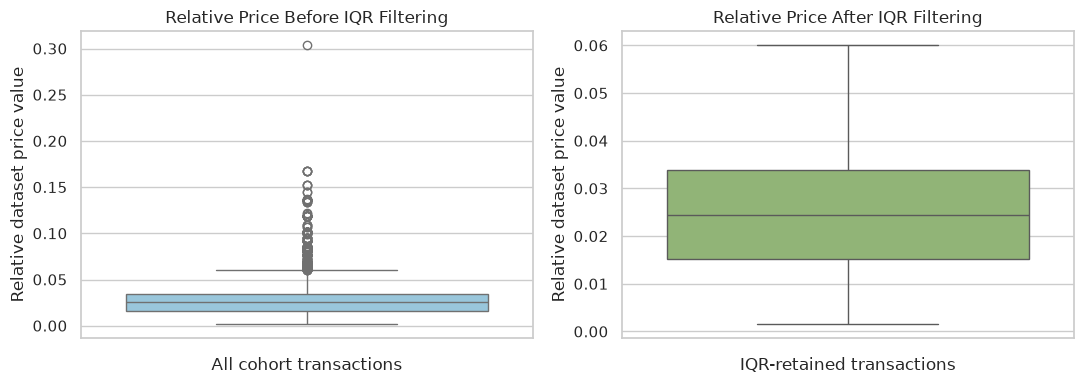

In [6]:
# Compute IQR bounds and compare the original distribution with a filtered copy.
price_outliers, iqr_lower, iqr_upper = analyzer.detect_outliers("unit_price", threshold=1.5)
filtered_frame = frame.loc[
    frame["unit_price"].between(iqr_lower, iqr_upper, inclusive="both")
].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=frame["unit_price"], ax=axes[0], color="#8ecae6")
axes[0].set_title("Relative Price Before IQR Filtering")
axes[0].set_xlabel("All cohort transactions")
axes[0].set_ylabel("Relative dataset price value")
sns.boxplot(y=filtered_frame["unit_price"], ax=axes[1], color="#90be6d")
axes[1].set_title("Relative Price After IQR Filtering")
axes[1].set_xlabel("IQR-retained transactions")
axes[1].set_ylabel("Relative dataset price value")
plt.tight_layout()
plt.show()

In [7]:
# Descriptive statistics and two numeric correlations.
descriptive_statistics = frame[
    ["unit_price", "age"]
].describe().round(4)
display(descriptive_statistics)
price_age_correlation = float(frame[["unit_price", "age"]].corr().iloc[0, 1])
image_text_correlation = float(
    sampled_correlation_features[["image_mean", "product_name_length"]].corr().iloc[0, 1]
)

def interpret_correlation(label, coefficient):
    magnitude = abs(coefficient)
    if magnitude < 0.10:
        strength = "negligible"
    elif magnitude < 0.30:
        strength = "weak"
    elif magnitude < 0.50:
        strength = "moderate"
    else:
        strength = "strong"
    direction = "positive" if coefficient > 0 else "negative" if coefficient < 0 else "zero"
    squared_percent = coefficient ** 2 * 100
    if squared_percent < 1:
        practical_signal = "little standalone linear signal"
    elif squared_percent < 9:
        practical_signal = "limited standalone linear signal"
    elif squared_percent < 25:
        practical_signal = "noticeable standalone linear signal"
    else:
        practical_signal = "substantial standalone linear signal"
    return (
        f"- {label}: r = {coefficient:+.3f}; {strength} {direction} association. "
        f"Squared magnitude = {squared_percent:.2f}%. This indicates {practical_signal} "
        "in this observational sample and does not imply causation."
    )

correlation_interpretations = "\n".join([
    interpret_correlation("Relative price and age", price_age_correlation),
    interpret_correlation("Image Mean and product-name length", image_text_correlation),
]) + (
    f"\n\nImage-feature correlation scope: {feature_product_count:,} deterministic sampled "
    f"products joined back to {sampled_transaction_count:,} transaction rows; "
    "the image summaries and correlations are transaction-weighted."
)
display(Markdown(correlation_interpretations))

,unit_price,age
count,9351.0000,9351.0000
mean,0.0279,35.2702
std,0.0180,12.4166
min,0.0015,17.0000
25%,0.0162,25.0000
50%,0.0254,31.0000
75%,0.0339,45.0000
max,0.3035,76.0000


- Relative price and age: r = +0.032; negligible positive association. Squared magnitude = 0.10%. This indicates little standalone linear signal in this observational sample and does not imply causation.
- Image Mean and product-name length: r = -0.148; weak negative association. Squared magnitude = 2.20%. This indicates limited standalone linear signal in this observational sample and does not imply causation.

Image-feature correlation scope: 64 deterministic sampled products joined back to 81 transaction rows; the image summaries and correlations are transaction-weighted.

### Correlation interpretation

- **Relative price and age:** `r = +0.032`; negligible positive association. The squared magnitude is 0.10%, so this provides little standalone linear signal.
- **Image Mean and product-name length:** `r = -0.148`; weak negative association. The squared magnitude is 2.20%, so this provides limited standalone linear signal.

These observational correlations do not imply causation. Image-feature results cover 64 deterministic sampled products joined back to 81 transaction rows and are transaction-weighted.

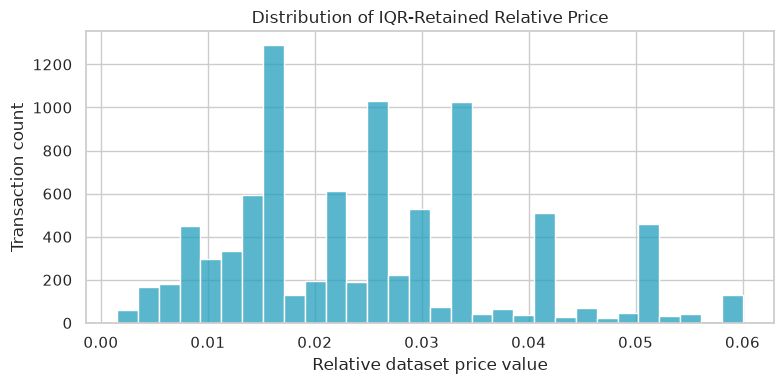

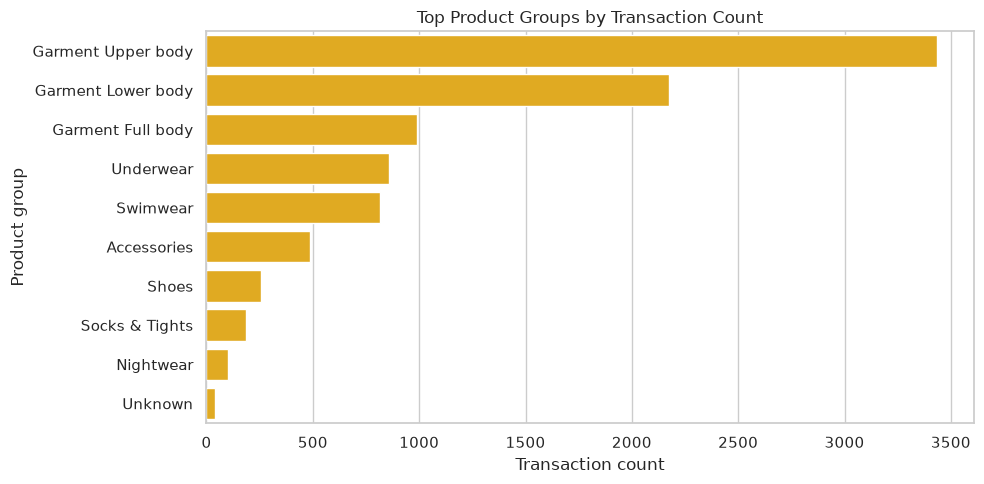

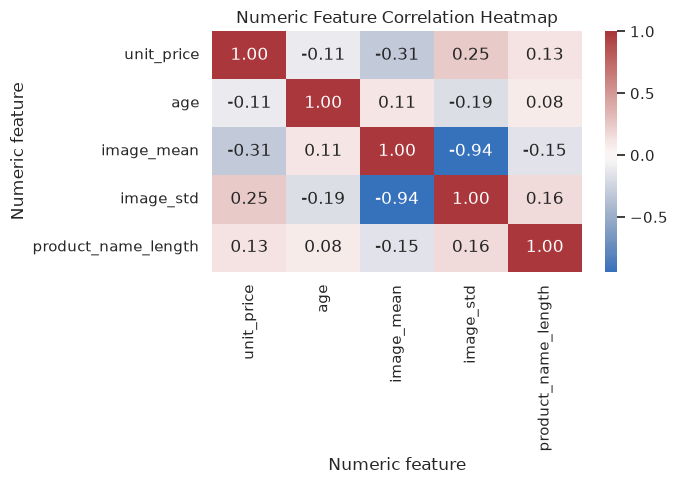

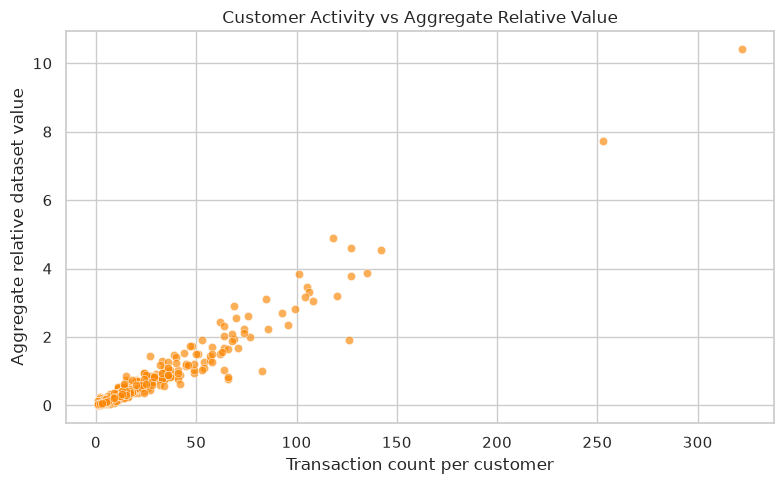

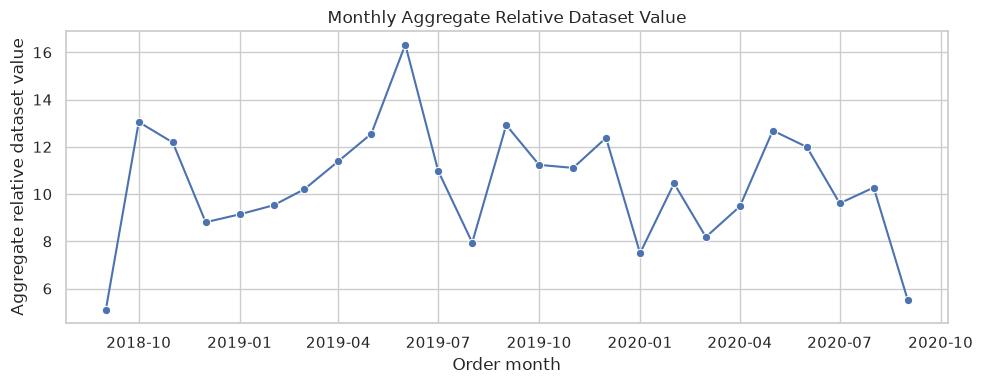

In [8]:
# 1. Histogram
plt.figure(figsize=(8, 4))
sns.histplot(data=filtered_frame, x="unit_price", bins=30, color="#219ebc")
plt.title("Distribution of IQR-Retained Relative Price")
plt.xlabel("Relative dataset price value")
plt.ylabel("Transaction count")
plt.tight_layout()
plt.show()

# 2. Category count bar
top_categories = frame["category"].value_counts().head(10).index
category_plot_data = frame.loc[frame["category"].isin(top_categories), ["category"]]
plt.figure(figsize=(10, 5))
sns.countplot(data=category_plot_data, y="category", order=top_categories, color="#ffb703")
plt.title("Top Product Groups by Transaction Count")
plt.xlabel("Transaction count")
plt.ylabel("Product group")
plt.tight_layout()
plt.show()

# 3. Numeric correlation heatmap
correlation_matrix = sampled_correlation_features[
    ["unit_price", "age", "image_mean", "image_std", "product_name_length"]
].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Numeric Feature Correlation Heatmap")
plt.xlabel("Numeric feature")
plt.ylabel("Numeric feature")
plt.tight_layout()
plt.show()

# 4. Aggregate customer scatterplot; no customer identifiers are rendered.
customer_aggregate = frame.groupby("customer_id", as_index=False).agg(
    transaction_count=("order_date", "size"),
    relative_value=("unit_price", "sum"),
)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=customer_aggregate,
    x="transaction_count",
    y="relative_value",
    alpha=0.65,
    color="#fb8500",
)
plt.title("Customer Activity vs Aggregate Relative Value")
plt.xlabel("Transaction count per customer")
plt.ylabel("Aggregate relative dataset value")
plt.tight_layout()
plt.show()

# 5. Monthly aggregate line chart
monthly_aggregate = (
    frame.set_index("order_date")["unit_price"].resample("MS").sum().rename("relative_value").reset_index()
)
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_aggregate, x="order_date", y="relative_value", marker="o")
plt.title("Monthly Aggregate Relative Dataset Value")
plt.xlabel("Order month")
plt.ylabel("Aggregate relative dataset value")
plt.tight_layout()
plt.show()

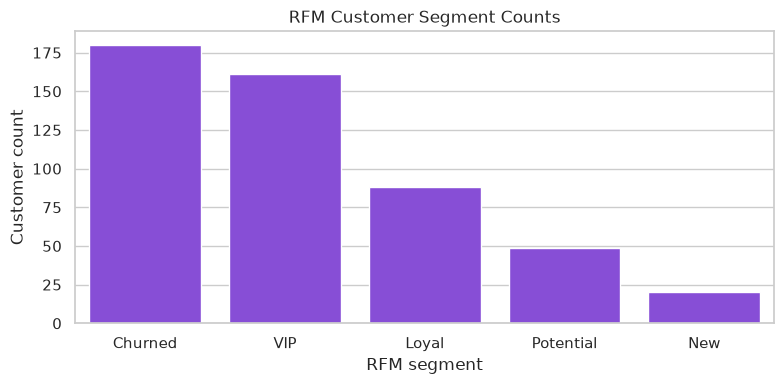

RFM은 498명의 표본 고객을 5개 세그먼트로 분류했습니다.

In [9]:
# RFM aggregates and segment-count chart; row-level customer IDs stay undisplayed.
rfm = analyzer.calculate_rfm(frequency_mode="unique_dates")
segment_counts = rfm["segment"].value_counts().sort_values(ascending=False)
segment_count = int(rfm["segment"].nunique())

plt.figure(figsize=(8, 4))
sns.countplot(
    data=rfm.reset_index(),
    x="segment",
    order=segment_counts.index,
    color="#8338ec",
)
plt.title("RFM Customer Segment Counts")
plt.xlabel("RFM segment")
plt.ylabel("Customer count")
plt.tight_layout()
plt.show()
display(Markdown(
    f"RFM은 {len(rfm):,}명의 표본 고객을 {segment_count}개 세그먼트로 분류했습니다."
))

In [10]:
# Compute three numeric findings and limitations from aggregate objects only.
outlier_rate = len(price_outliers) / len(frame)
largest_segment = str(segment_counts.index[0])
largest_segment_share = float(segment_counts.iloc[0] / len(rfm))
monthly_peak = float(monthly_aggregate["relative_value"].max())
limitations = (
    "이 결과는 결정적 방식으로 선택된 500명 표본의 관찰적 기술 분석입니다. "
    "price는 relative dataset value일 뿐 특정 통화 금액이 아닙니다. "
    f"상품명 길이는 전체 {len(frame):,}개 거래 행에 Pandas 문자열 연산을 적용했습니다. "
    f"이미지 Mean/Std만 메모리 경계를 위해 결정적으로 선택한 {feature_product_count}개 상품 표본에서 계산했고, "
    f"이를 {sampled_transaction_count:,}개 거래 행에 다시 결합했으므로 이미지 요약과 상관계수는 "
    "transaction-weighted 통계입니다. "
    "NumPy Mean/Std로 축약되어 색상·형태의 모든 의미를 보존하지 않으며, "
    "상관관계는 인과관계를 뜻하지 않습니다."
)
display(Markdown(f'''### Numeric findings and limitations

1. age 결측률은 그룹별 대치 전 **{age_missing_rate:.2%}**였고 대치 후 결측치는 **{age_missing_after:,}건**입니다.
2. IQR 경계 밖 relative price 관측치는 **{outlier_rate:.2%}**입니다.
3. 가장 큰 RFM 세그먼트는 **{largest_segment}**이며 표본 고객의 **{largest_segment_share:.2%}**입니다. 월별 aggregate peak는 **{monthly_peak:.4f}**입니다.

**Limitations:** {limitations}
'''))

### Numeric findings and limitations

1. age 결측률은 그룹별 대치 전 **0.77%**였고 대치 후 결측치는 **0건**입니다.
2. IQR 경계 밖 relative price 관측치는 **5.11%**입니다.
3. 가장 큰 RFM 세그먼트는 **Churned**이며 표본 고객의 **36.14%**입니다. 월별 aggregate peak는 **16.3281**입니다.

**Limitations:** 이 결과는 결정적 방식으로 선택된 500명 표본의 관찰적 기술 분석입니다. price는 relative dataset value일 뿐 특정 통화 금액이 아닙니다. 상품명 길이는 전체 9,351개 거래 행에 Pandas 문자열 연산을 적용했습니다. 이미지 Mean/Std만 메모리 경계를 위해 결정적으로 선택한 64개 상품 표본에서 계산했고, 이를 81개 거래 행에 다시 결합했으므로 이미지 요약과 상관계수는 transaction-weighted 통계입니다. NumPy Mean/Std로 축약되어 색상·형태의 모든 의미를 보존하지 않으며, 상관관계는 인과관계를 뜻하지 않습니다.
